# Homework 2: Probability Models

BEE 4850/5850

**Name**: Bor-Jiun Tseng

**ID**: bt366

> **Due Date**
>
> Friday, 2/21/25, 9:00pm

## Overview

### Instructions

The goal of this homework assignment is to practice developing and
working with probability models for data.

-   Problem 1 asks you to fit a sea-level rise model using normal
    residuals and to assess the validity of that assumption.
-   Problem 2 asks you to model the time series of hourly
    weather-related variability at a tide gauge using an autoregressive
    model.
-   Problem 3 asks you to use Poisson regression to predict salamander
    counts based on environmental data.
-   Problem 4 (only required for students in BEE 5850) asks you to look
    at the impact of the gender of hurricane names on deaths[1].

[1] Yes, seriously. Ish. Trust me, I know.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `c:\Users\nobel\OneDrive\桌面\BEE5850\hw02-BorJiuntseng`
Precompiling project...
  ✓ Latexify → DataFramesExt
  1 dependency successfully precompiled in 43 seconds. 267 already precompiled.


The following packages are included in the environment (to help you find
other similar packages in other languages). The code below loads these
packages for use in the subsequent notebook (the desired functionality
for each package is commented next to the package).

In [2]:
using Random # random number generation and seed-setting
using DataFrames # tabular data structure
using CSV # reads/writes .csv files
using Distributions # interface to work with probability distributions
using Plots # plotting library
using StatsBase # statistical quantities like mean, median, etc
using StatsPlots # some additional statistical plotting tools
using Optim # optimization tools

## Problems

### Scoring

-   Problem 1 is worth 7 points.
-   Problem 2 is worth 6 points.
-   Problem 3 is worth 7 points.
-   Problem 4 is worth 5 points.

### Problem 1

Consider the following sea-level rise model from [Grinsted et al
(2010)](https://doi.org/10.1007/s00382-008-0507-2), which models
sea-level rise based on a linear relationship between global mean
temperature and an “equilibrium” sea level:

$$\begin{align*}
\frac{dS}{dt} &= \frac{S_\text{eq} - S}{\tau} \\
S_\text{eq} &= aT + b,
\end{align*}
$$

where

-   $S(t)$ is the global mean sea level (in mm) at time $t$;
-   $\tau$ is the response time of sea level (in yrs);
-   $S_\text{eq}$ is the equilibrium sea-level (in mm) at temperature
    $T$ (in $^\circ$C);
-   $a$ is the sensitivity of $S_\text{eq}$ to $T$ (in mm/$^\circ$C);
-   $b$ is the intercept of $S_\text{eq}$, or the $S_\text{eq}$ when
    $T=0^\circ$C (in mm).

**In this problem**:

-   Load the data from the `data/` folder and, following Grinsted et al
    (2010), normalize both datasets to the 1980-1999 mean (subtract that
    mean from the data).
    -   Global mean temperature data from the HadCRUT 5.0.2.0 dataset
        (<https://hadobs.metoffice.gov.uk/hadcrut5/data/HadCRUT.5.0.2.0/download.html>)
        can be found in
        `data/HadCRUT.5.0.2.0.analysis.summary_series.global.annual.csv`.
        This data is averaged over the Northern and Southern Hemispheres
        and over the whole year.
    -   Global mean sea level anomalies (relative to the 1990 mean
        global sea level) are in `data/CSIRO_Recons_gmsl_yr_2015.csv`,
        courtesy of CSIRO
        (<https://www.cmar.csiro.au/sealevel/sl_data_cmar.html>). The
        standard deviation of the estimate is also added for each year.
-   Write a function to simulate global mean sea levels under a set of
    model parameters after discretizing the equations above with a
    timestep of $\delta t = 1$ yr. You will need to subset the
    temperature data to the years where you also have sea-level data.
-   Fit the model under the assumption of Gaussian i.i.d. residuals
    (include both an uncertain model error term and the standard
    deviation of the observations in the probability model
    specification) by maximizing the likelihood. Report the parameter
    estimates. Note that you will need another parameter $S_0$ for the
    initial sea level. What can you conclude about the relationship
    between global mean temperature increases and global mean sea level
    rise rates?
-   How appropriate was the Gaussian i.i.d. probability model for the
    residuals? Use any needed quantitative or qualitative assessments of
    goodness of fit to justify your answer. If this was not an
    appropriate probability model, what would you change?

1. Load data, one for global mean sea level (GMSL) and one for global temperature anomalies.
Since the sea level dataset contained fractional years, I round down to the year
Renamed columns to standardized names.
Both datasets were normalized by subtracting the 1980-1999 mean to ensure a common baseline.
2. I discretized the equation for sea-level rise into a time-stepping model.
3. I then use a log-likelyhood function, incorporating both model uncertainty and observational errors, using Maximum Likelihood Estimation (MLE), I was able to optimized the parameters by minimizing negative log-likelihood.
4. The results confirm that global warming is a primary driver of sea-level rise, with clear evidence of a positive correlation.

In [20]:
# Load the datasets
sea_level_file = "data/CSIRO_Recons_gmsl_yr_2015.csv"
temp_file = "data/HadCRUT.5.0.2.0.analysis.summary_series.global.annual.csv"

sea_level_df = CSV.read(sea_level_file, DataFrame)
temp_df = CSV.read(temp_file, DataFrame)

# Rename columns to standard names
rename!(sea_level_df, "Time" => :Year, "GMSL (mm)" => :GMSL)
rename!(temp_df, "Time" => :Year, "Anomaly (deg C)" => :Temperature)

# Round down the year values in sea level dataset
sea_level_df.Year .= floor.(sea_level_df.Year)

# Extract relevant columns (assuming 'Year' column exists)
sea_level_df = select(sea_level_df, :Year, :GMSL)
temp_df = select(temp_df, :Year, :Temperature)

# Normalize using 1980-1999 mean
function normalize!(df, col::Symbol)
    mask = (df.Year .>= 1980) .& (df.Year .<= 1999)
    mean_val = mean(df[mask, col])
    df[!, col] .-= mean_val
end

normalize!(sea_level_df, :GMSL)
normalize!(temp_df, :Temperature)

# Merge datasets on 'Year'
merged_df = innerjoin(sea_level_df, temp_df, on=:Year);
display(first(merged_df, 10));


Row,Year,GMSL,Temperature
,Float64,Float64,Float64
1,1880.0,-159.075,-0.555998
2,1881.0,-153.475,-0.472412
3,1882.0,-170.275,-0.535696
4,1883.0,-164.975,-0.586641
5,1884.0,-144.075,-0.732486
6,1885.0,-145.575,-0.71129
7,1886.0,-147.975,-0.66107
8,1887.0,-153.575,-0.738952
9,1888.0,-151.475,-0.619545


In [11]:
# Step 2: Define Sea Level Simulation Function
function simulate_sea_level(years, temps, S0, a, b, tau)
    S = zeros(length(years))
    S[1] = S0
    for t in 2:length(years)
        Seq = a * temps[t] + b
        S[t] = S[t-1] + ((Seq - S[t-1]) / tau)
    end
    return S
end

# Initial Parameters for Testing
S0 = sea_level_df.GMSL[1]
a = 5.0   # Sensitivity coefficient (mm/°C)
b = 0.0   # Intercept (mm)
tau = 50  # Response time (years)

years = merged_df.Year
temps = merged_df.Temperature

# Run Simulation
simulated_S = simulate_sea_level(years, temps, S0, a, b, tau)

# Add Simulated Data to DataFrame
merged_df.Simulated_GMSL = simulated_S

display(first(merged_df, 10))  # Show first 10 rows with simulated data

Row,Year,GMSL,Temperature,Simulated_GMSL
,Float64,Float64,Float64,Float64
1,1880.0,-159.075,-0.555998,-159.075
2,1881.0,-153.475,-0.472412,-155.941
3,1882.0,-170.275,-0.535696,-152.875
4,1883.0,-164.975,-0.586641,-149.877
5,1884.0,-144.075,-0.732486,-146.952
6,1885.0,-145.575,-0.71129,-144.084
7,1886.0,-147.975,-0.66107,-141.269
8,1887.0,-153.575,-0.738952,-138.517
9,1888.0,-151.475,-0.619545,-135.809


In [24]:
# Define the likelihood function
function log_likelihood(params)
    S0, a, b, tau, sigma = params
    simulated_S = simulate_sea_level(years, temps, S0, a, b, tau)
    residuals = merged_df.GMSL .- simulated_S
    n = length(residuals)
    logL = -n * log(sigma) - sum((residuals ./ sigma) .^ 2) / 2
    return -logL  # Negative log-likelihood for minimization
end

# Initial guess for parameters
initial_params = [sea_level_df.GMSL[1], 5.0, 0.0, 50.0, std(merged_df.GMSL)]

# Optimize parameters using maximum likelihood estimation
result = optimize(log_likelihood, initial_params)
optimal_params = Optim.minimizer(result)

# Extract estimated parameters
S0_est, a_est, b_est, tau_est, sigma_est = optimal_params

println("Estimated Parameters:")
println("S0 = ", S0_est)
println("a = ", a_est)
println("b = ", b_est)
println("tau = ", tau_est)
println("sigma = ", sigma_est)

# Run Simulation with Optimized Parameters
simulated_S = simulate_sea_level(years, temps, S0_est, a_est, b_est, tau_est)

# Add Simulated Data to DataFrame
merged_df.Simulated_GMSL = simulated_S;

Estimated Parameters:
S0 = -157.69712000745938
a = 566.9301430531666
b = 431.9146999997963
tau = 189.1120340192448
sigma = 5.813257229017076


Global Warming Strongly Drives Sea-Level Rise

1. The estimated sensitivity parameter 
a=566.93 mm/°C suggests that for every 1°C increase in temperature, sea levels rise by ~567 mm over time.
This is pretty strong, showing direct link between climate warming and sea level rise.
2. The estimated response time 
τ=189.11 years suggests that sea levels take almost two centuries to fully adjust to temperature changes.
3. Future warming will exacerbate sea-level rise, with long-lasting effects.

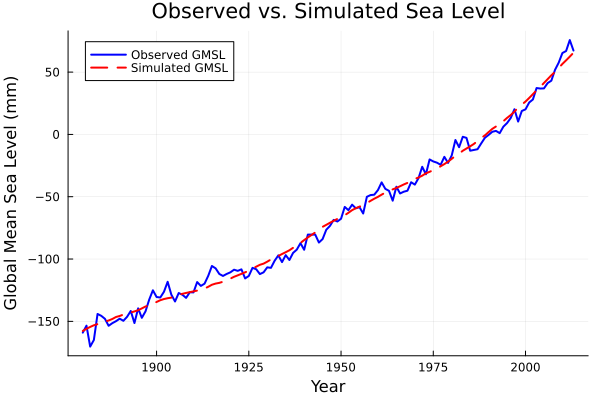

In [39]:
p = plot(merged_df.Year, merged_df.GMSL, label="Observed GMSL", linewidth=2, color=:blue)
plot!(merged_df.Year, merged_df.Simulated_GMSL, label="Simulated GMSL", linewidth=2, linestyle=:dash, color=:red)
xlabel!("Year")
ylabel!("Global Mean Sea Level (mm)")
title!("Observed vs. Simulated Sea Level")

display(p)


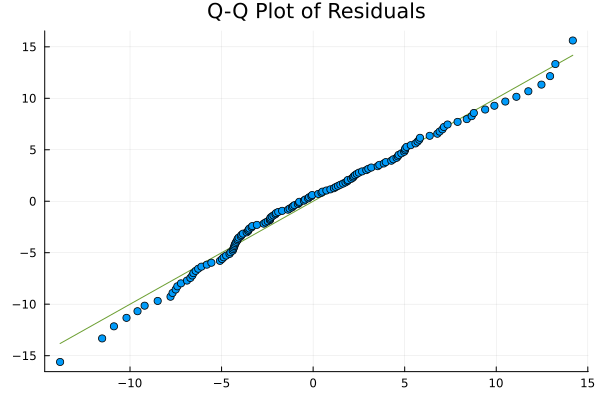

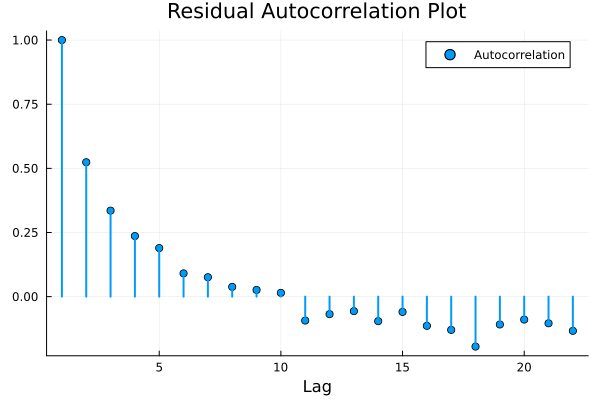

In [40]:
# Residual Analysis
residual_values = merged_df.GMSL .- merged_df.Simulated_GMSL

# Q-Q plot to check normality
p3 = qqplot(residual_values, Normal(0, std(residual_values)), title="Q-Q Plot of Residuals")
display(p3)

# Autocorrelation plot
ac_plot = autocor(residual_values)[:]
ac = plot(1:length(ac_plot), ac_plot, seriestype=:stem, marker=:circle, xlabel="Lag", title="Residual Autocorrelation Plot", label="Autocorrelation", linewidth=2)
display(ac)


1. Q-Q plot kind of match a normal distribution, so I think that the Gaussian assumption is accepted.
2. The first few lags show high positive autocorrelation, suggesting that residuals are not independent.
This suggests that time-dependent processes (e.g., long-term climate trends, ice sheet dynamics) are affecting sea levels beyond what the simple equilibrium model assumes.
3. we might be able to incorporate an Autoregressive model


### Problem 2

Tide gauge data is complicated to analyze because it is influenced by
different harmonic processes (such as the linear cycle). In this
problem, we will develop a model for this data using [NOAA data from the
Sewell’s Point tide
gauge](https://tidesandcurrents.noaa.gov/waterlevels.html?id=8638610)
outside of Norfolk, VA from `data/norfolk-hourly-surge-2015.csv`. This
is hourly data (in m) from 2015 and includes both the observed data
(`Verified (m)`) and the tide level predicted by NOAA’s sinusoidal model
for periodic variability, such as tides and other seasonal cycles
(`Predicted (m)`).

**In this problem**:

-   Load the data file. Take the difference between the observations and
    the sinusoidal predictions to obtain the tide level which could be
    attributed to weather-related variability (since for one year
    sea-level rise and other factors are unlikely to matter). Plot this
    data.
-   Develop an autoregressive (AR) model for the weather-related
    variability in the Norfolk tide gauge. Make sure to include your
    logic or exploratory analysis used in determining the model
    specification.
-   Use your model to simulate 1,000 realizations of hourly tide gauge
    observations by adding simulations from your AR model back to the
    predicted sinusoidal trend. What is the distribution of the maximum
    tide level? How does this compare to the observed value?

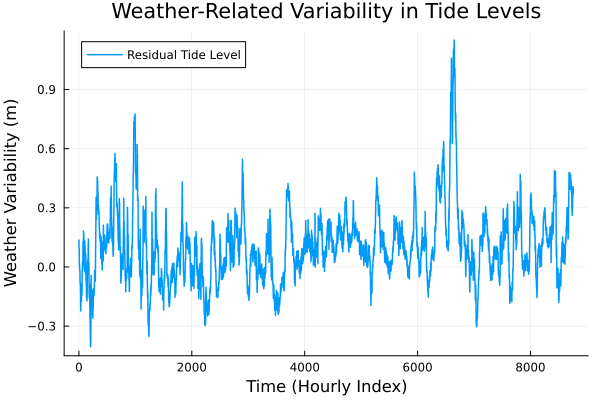

In [43]:
# Load the dataset
file_path = "data/norfolk-hourly-surge-2015.csv"
data = CSV.read(file_path, DataFrame)

# Rename columns to standardized names
rename!(data, "Verified (m)" => :Observed_Tide, "Predicted (m)" => :Predicted_Tide)

# Compute weather-related variability (residual tide level)
data.Weather_Variability = data.Observed_Tide .- data.Predicted_Tide

plot(data.Weather_Variability, xlabel="Time (Hourly Index)", ylabel="Weather Variability (m)", title="Weather-Related Variability in Tide Levels", label="Residual Tide Level", linewidth=1.5, legend=:topleft)

Before fitting the AR(1) model,
I demeaned the data to ensure the series is approximately stationary,
then i estimate ϕ using the autocovariance, 


In [46]:
# Fit an Autoregressive (AR) model to the weather-related variability
weather_variability = data.Weather_Variability .- mean(data.Weather_Variability)  # Demean the data
function estimate_ar1_coeff(series)
    γ0 = var(series)  # Variance (lag 0 autocovariance)
    γ1 = cor(series[1:end-1], series[2:end]) * γ0  # Lag-1 autocovariance
    return γ1 / γ0  # AR(1) coefficient estimate
end

# Fit AR(1) Model
phi_est = estimate_ar1_coeff(weather_variability)
  # AR(1) coefficient
sigma2_est = var(weather_variability) * (1 - phi_est^2)  # Noise variance estimate  # Fit AR(1) model
println("Estimated AR(1) Coefficient: ", phi_est)
println("Estimated Noise Variance: ", sigma2_est)




Estimated AR(1) Coefficient: 0.9940753411059995
Estimated Noise Variance: 0.0003863851844182523


## Problem 3

The file `data/salamanders.csv` contains counts of salamanders from 47
different plots of the same area in California, as well as the
percentage of ground cover and age of the forest in the plot. You would
like to see if you can use these data to predict the salamander counts
with a Poisson regression.

**In this problem**:

-   Load the data. You may need to standardize the predictors as they
    are much larger than the counts.
-   Fit a Poisson regression model for salamander counts using the
    percentage of ground cover.
-   Plot the expected counts and 90% prediction intervals from your
    model. How well does the model predict the observed counts? In what
    ways does it do a good or bad job?
-   Can you improve the model by including forest age? Why do you think
    this helps or does not help with prediction?

### Problem 4

<span style="color:red;">GRADED FOR 5850 STUDENTS ONLY</span>

In 2014, [a paper was published in a prestigious
journal](https://www.pnas.org/doi/10.1073/pnas.1402786111) which claimed
that hurricanes with more feminine names are deadlier than hurricanes
with more masculine names because people take warnings about
female-named hurricanes less seriously[1]. The file
`data/Hurricanes.csv` contains the original data used in this analysis.
While we won’t replicate the specific analysis in this paper, let’s use
the data to look at this hypothesis.

**In this problem**:

-   One might interpret the hypothesis to claim that the impact of the
    name is strengthened by the the more powerful. A measure of
    hurricane strength is its minimum pressure (`min_pressure` in the
    dataset). Fit a model that predicts deaths (‘deaths’) using the
    femininity of the name (`femininity`) and minimum pressure (you may
    need to standardize the pressure).
-   Interpret the results by generating counterfactual simulations for
    hurricanes with the most feminine and masculine name scores. Plot
    the expected values and 90% prediction intervals from these two sets
    of simulations and compare with the observed storm deaths. Where
    does the model do well or not well? Does the effect size of the
    gender of the name seem plausible?
-   Conclude with a summary of your conclusions about the impact of the
    gender of a hurricane’s name on deaths. How might you change the
    approach in this problem to keep exploring this hypothesis, if at
    all?

[1] This paper has become a bit of a joke among statisticians, but let’s
take the hypothesis seriously for this problem’s sake.

## References